<a href="https://colab.research.google.com/github/lakshmiramki2008-dotcom/codealpha_tasks-/blob/main/codealpha_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('car data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Display the shape of the DataFrame
print(f"Shape of the DataFrame: {df.shape}")

# Display information about the DataFrame (data types, non-null values)
display(df.info())

# Display descriptive statistics of the DataFrame
display(df.describe())

Shape of the DataFrame: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
# Print unique values of 'Fuel_Type' column
print('Fuel Types:', df['Fuel_Type'].unique())

# Print unique values of 'Selling_type' column
print('Selling Types:', df['Selling_type'].unique())

# Print unique values of 'Transmission' column
print('Transmission Types:', df['Transmission'].unique())

Fuel Types: ['Petrol' 'Diesel' 'CNG']
Selling Types: ['Dealer' 'Individual']
Transmission Types: ['Manual' 'Automatic']


In [ ]:
# Create a new feature 'no_year' representing the number of years since the car was made
df['no_year'] = 2020 - df['Year']

# Drop the original 'Year' and 'Car_Name' columns as they are no longer needed or useful for prediction
df.drop(['Year', 'Car_Name'], axis=1, inplace=True)

# Convert categorical features into numerical using one-hot encoding
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

# Drop the 'Owner' column as its unique values are '0', '1', and '3' which does not give a clear meaning.
df.drop('Owner', axis=1, inplace=True)

# Display the first 5 rows of the modified DataFrame
display(df.head())

,Selling_Price,Present_Price,Driven_kms,no_year,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,6,False,True,False,True
1,4.75,9.54,43000,7,True,False,False,True
2,7.25,9.85,6900,3,False,True,False,True
3,2.85,4.15,5200,9,False,True,False,True
4,4.60,6.87,42450,6,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (240, 7)
X_test shape: (61, 7)
y_train shape: (240,)
y_test shape: (61,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the training and testing data
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluate the model using R-squared score
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R-squared on training data: {r2_train:.2f}")
print(f"R-squared on testing data: {r2_test:.2f}")

R-squared on training data: 0.98
R-squared on testing data: 0.96


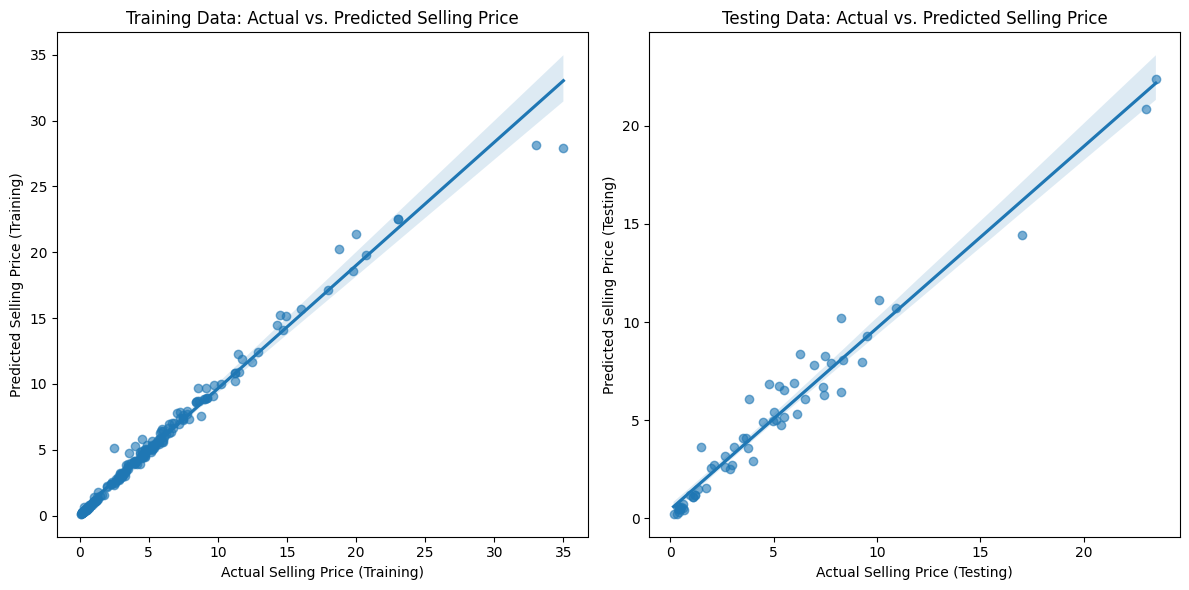

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot for training data
plt.subplot(1, 2, 1)
sns.regplot(x=y_train, y=y_train_pred, scatter_kws={'alpha':0.6})
plt.xlabel('Actual Selling Price (Training)')
plt.ylabel('Predicted Selling Price (Training)')
plt.title('Training Data: Actual vs. Predicted Selling Price')

# Plot for testing data
plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_test_pred, scatter_kws={'alpha':0.6})
plt.xlabel('Actual Selling Price (Testing)')
plt.ylabel('Predicted Selling Price (Testing)')
plt.title('Testing Data: Actual vs. Predicted Selling Price')

plt.tight_layout()
plt.show()